In [36]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    print("directory path is not in the system path")
    sys.path.append(str(dir))
    print("adding directory...")
else:
    print("Directory already exists in the system path")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
directory path is not in the system path
adding directory...


In [37]:
import torch
from pathlib import Path
from nn import Unet1D
from config import Config
from utils import posterior_beta, log_transform, inverse_standard
from diffusion import reverse
import time
import yfinance as yf
import math
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from numpy.lib.stride_tricks import sliding_window_view
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from arch import arch_model

In [3]:
ticker = "^GSPC"
start_interval = "2016-12-01"
end_interval = "2026-01-01"
interval = "1d" 

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2

train_raw_snp500 = raw_snp500[:val_split]
train_snp500 = log_transform(train_raw_snp500)
window = 256

In [4]:
DIR = Path().resolve().parents[1] / "models" / "model_v0.pth"
assert DIR.exists(), "model doesnt exist"
DIR = str(DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [5]:
T = 1000

config = Config().set_model_config(
  attn_res=16,
  n_res_block=2,
  T=T,
  num_heads=4,
  encoder_in_channels=[1, 4, 8, 16],
  encoder_out_channels=[4, 8, 16, 32],
  decoder_in_channels=[32, 16, 8, 4],
  decoder_out_channels=[16, 8, 4, 1]
)

In [6]:
model_v0 = Unet1D(**config.model_config)

In [7]:
checkpoint = torch.load(DIR, weights_only=True)
model_v0.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [8]:
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

xT = torch.randn(size=(32, 1, window))
posterior_betas = torch.tensor([posterior_beta(alpha_hats=alpha_hats, betas=betas, t=t) for t in range(T)])

In [9]:
posterior_betas.size()

torch.Size([1000])

In [10]:
alpha_hats.size()

torch.Size([1000])

In [11]:
reverse_time = time.time()

scaled_synthetic_data = reverse(
  xT=xT,
  T=T,
  betas=betas,
  posterior_betas=posterior_betas,
  alpha_bars=alpha_hats,
  model=model_v0
).squeeze(1).detach().numpy()

reverse_time = time.time() - reverse_time
print(f"Reverse process duration : { reverse_time:.2f} seconds")

Reverse process duration : 91.69 seconds


In [12]:
# inverse scaling
synthetic_data = inverse_standard(scaled_synthetic_data, train_snp500)
synthetic_data[:1]

array([[ 5.92370483e-03,  1.64673065e-03,  8.33216626e-03,
         1.43181349e-02, -7.72775205e-03,  3.24132898e-03,
         5.05596181e-03,  1.06411661e-02,  2.29491495e-03,
        -7.24347664e-04,  9.27905680e-03, -2.09145836e-03,
        -7.05075426e-03,  2.07207628e-02, -1.59576779e-02,
        -4.50637622e-03,  8.87070770e-03,  1.10297902e-02,
        -3.03463492e-03,  2.16768043e-04,  2.13951244e-02,
         2.17419109e-03, -9.00358690e-04, -1.14722229e-02,
        -2.17836141e-02,  1.02183797e-02, -5.06989081e-03,
         2.58590357e-03,  1.06295409e-02, -9.34228260e-03,
        -9.29354441e-03,  1.63236053e-02, -6.37667266e-03,
         3.04795300e-02,  1.25522142e-02, -3.81155575e-03,
        -8.07658447e-03,  5.17549074e-03, -3.84719817e-03,
         4.73026461e-04, -1.06090894e-03,  1.01876519e-02,
        -2.22503919e-02,  1.22342086e-02, -6.28055248e-03,
         9.95362590e-03,  3.01196758e-03, -1.82297715e-02,
         2.52352882e-04,  9.80887874e-04,  1.51455155e-0

In [13]:
synthetic_data.shape

(32, 256)

In [16]:
stride = window

empirical_window = []
for i in range(0, len(train_snp500) - window + 1, stride):
    empirical_window.append(train_snp500[i:i+window])

empirical_window = np.array(empirical_window)

In [17]:
len(empirical_window)

5

### Normal Plot

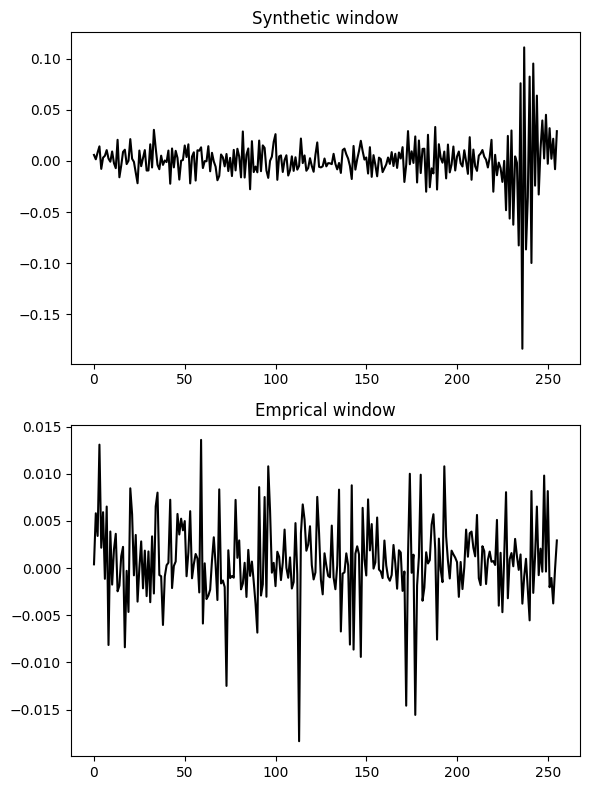

In [18]:
"""
  Note that the generated synthetic window cant be indexed by time since it doesnt preserve time index.
  We would label it as what a typical n-window return looked like from the training data.
"""

fig, ax = plt.subplots(figsize=(6, 8), nrows=2)

ax[0].plot(synthetic_data[0], c="black")
ax[1].plot(empirical_window[0], c="black")
ax[0].set_title("Synthetic window")
ax[1].set_title("Emprical window")

fig.tight_layout()
plt.show()

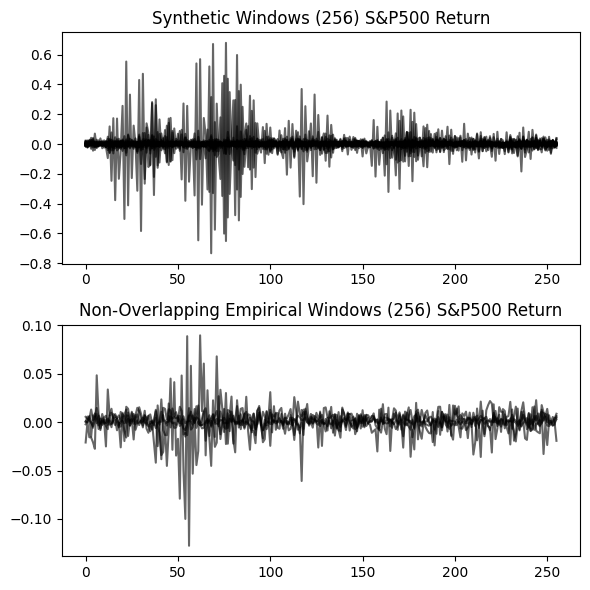

In [19]:
fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
for i in range(len(synthetic_data)):
  ax[0].plot(synthetic_data[i], alpha=0.6, c="black")

ax[0].set_title(f"Synthetic Windows ({window}) S&P500 Return")

for i in range(len(empirical_window)):
  ax[1].plot(empirical_window[i], alpha=0.6, c="black")

ax[1].set_title(f"Non-Overlapping Empirical Windows ({window}) S&P500 Return")

fig.tight_layout()
plt.show()

In [20]:
emp_copy = empirical_window.copy()

print(emp_copy[0][-1])

emp_copy = emp_copy.reshape(-1)
print(emp_copy[255])

0.002928067010109385
0.002928067010109385


In [21]:
a = torch.randn(2, 2, 2)

print(a)

a = a.reshape(-1)
a.size()

print(a)

tensor([[[ 1.1643, -0.2742],
         [-0.1347, -0.3740]],

        [[ 0.2490, -1.1351],
         [ 0.3260, -0.1750]]])
tensor([ 1.1643, -0.2742, -0.1347, -0.3740,  0.2490, -1.1351,  0.3260, -0.1750])


### Stationarity Tests

In [74]:
def test_stationarity(windows, maxlag=10, regression="ct"):
  n = len(windows)
  result = []

  for i in range(n):
    res = adfuller(windows[i], maxlag=maxlag, regression=regression)
    result.append(res)

  return result

In [78]:
adf_emp = test_stationarity(empirical_window)
adf_syn = test_stationarity(synthetic_data)

In [79]:
for idx, res in enumerate(adf_emp):
  adf_statistic = res[0]
  critical_values = res[4]

  print("="*10 + f"ADF Test at window-{idx + 1}" + "="*10)
  print(f"ADF Test Statistic: {adf_statistic}")
  print(f"1% Critical Value: {critical_values['1%']}")
  print(f"5% Critical Value: {critical_values['5%']}")
  print(f"10% Critical Value: {critical_values['10%']}")

==========ADF Test at window-1==========
ADF Test Statistic: -18.12440188966431
1% Critical Value: -3.9947176293431634
5% Critical Value: -3.4278489532834278
10% Critical Value: -3.1372513189497253
==========ADF Test at window-2==========
ADF Test Statistic: -7.012217788248178
1% Critical Value: -3.995745444647188
5% Critical Value: -3.4283431178407486
10% Critical Value: -3.137541090692239
==========ADF Test at window-3==========
ADF Test Statistic: -16.992414637231505
1% Critical Value: -3.9947176293431634
5% Critical Value: -3.4278489532834278
10% Critical Value: -3.1372513189497253
==========ADF Test at window-4==========
ADF Test Statistic: -4.207196547682353
1% Critical Value: -3.995897093341176
5% Critical Value: -3.42841601911857
10% Critical Value: -3.13758383611086
==========ADF Test at window-5==========
ADF Test Statistic: -17.243977276454707
1% Critical Value: -3.9947176293431634
5% Critical Value: -3.4278489532834278
10% Critical Value: -3.1372513189497253


In [82]:
rejections = 0

for idx, res in enumerate(adf_syn):
  adf_statistic = res[0]
  critical_values = res[4]

  print("="*10 + f"ADF Test at window-{idx + 1}" + "="*10)
  print(f"ADF Test Statistic: {adf_statistic}")
  print(f"1% Critical Value: {critical_values['1%']}")
  print(f"5% Critical Value: {critical_values['5%']}")
  print(f"10% Critical Value: {critical_values['10%']}")

  if adf_statistic < critical_values["5%"]:
    rejections += 1

==========ADF Test at window-1==========
ADF Test Statistic: -3.888505836062318
1% Critical Value: -3.9960499911680953
5% Critical Value: -3.4284895182621864
10% Critical Value: -3.1376269313174987
==========ADF Test at window-2==========
ADF Test Statistic: -5.552291230451377
1% Critical Value: -3.995745444647188
5% Critical Value: -3.4283431178407486
10% Critical Value: -3.137541090692239
==========ADF Test at window-3==========
ADF Test Statistic: -3.393361690852763
1% Critical Value: -3.996204153626465
5% Critical Value: -3.428563622657226
10% Critical Value: -3.1376703806237196
==========ADF Test at window-4==========
ADF Test Statistic: -3.807093636181889
1% Critical Value: -3.996204153626465
5% Critical Value: -3.428563622657226
10% Critical Value: -3.1376703806237196
==========ADF Test at window-5==========
ADF Test Statistic: -4.087364474075313
1% Critical Value: -3.9960499911680953
5% Critical Value: -3.4284895182621864
10% Critical Value: -3.1376269313174987
==========ADF Te

In [83]:
print(f"Rejection rate : {rejections / len(synthetic_data):.2f}")

Rejection rate : 0.94


### Theoretical Distribution Comparison  

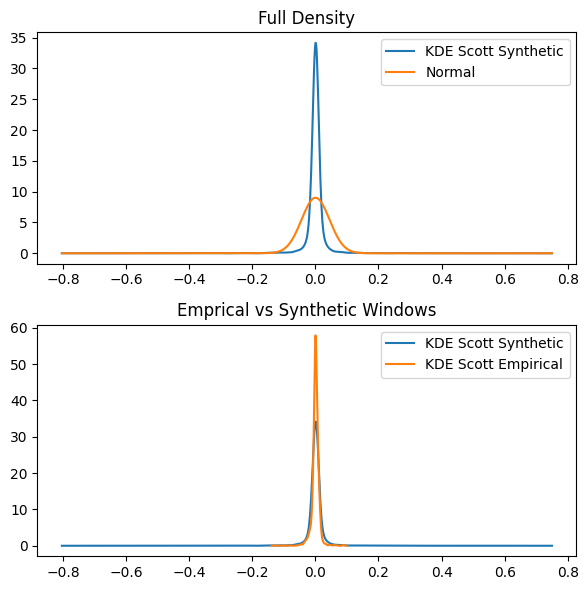

In [22]:
k = 3
std = synthetic_data.reshape(-1).std()
mu = synthetic_data.reshape(-1).mean()
n = min(len(synthetic_data.reshape(-1)), len(empirical_window.reshape(-1)))

data_min = synthetic_data.reshape(-1).min()
data_max = synthetic_data.reshape(-1).max()
padding = 0.05 * (data_max - data_min)

data_min_emp = empirical_window.reshape(-1).min()
data_max_emp = empirical_window.reshape(-1).max()
padding_emp = 0.05 * (data_max_emp - data_min_emp)

xmin = data_min - padding
xmax = data_max + padding

xmin_emp = data_min_emp - padding_emp
xmax_emp = data_max_emp + padding_emp

x = np.linspace(xmin, xmax, 1000)
kde = stats.gaussian_kde(synthetic_data.reshape(-1))

x_emp = np.linspace(xmin_emp, xmax_emp, 1000)
kde_emp = stats.gaussian_kde(empirical_window.reshape(-1))

# theoretical samples
norm = stats.norm(
    loc=mu,
    scale=std,
)

fig, ax = plt.subplots(figsize=(6, 6), nrows=2)
ax[0].plot(x, kde(x), label="KDE Scott Synthetic")
ax[0].plot(x, norm.pdf(x), label="Normal")
ax[0].set_title("Full Density")
ax[0].legend()

# ax[1].plot(x, kde(x), label="KDE Scott Synthetic")
# ax[1].plot(x, norm.pdf(x), label="Normal")
# ax[1].set_title("Tail Comparison")
# ax[1].set_yscale("log")
# ax[1].legend()

ax[1].plot(x, kde(x), label="KDE Scott Synthetic")
ax[1].plot(x_emp, kde_emp(x_emp), label="KDE Scott Empirical")
ax[1].set_title("Emprical vs Synthetic Windows")
# ax[1].set_yscale("log")
ax[1].legend()

# ax[3].plot(x, kde(x), label="KDE Scott Synthetic")
# ax[3].plot(x_emp, kde_emp(x_emp), label="KDE Scott Empirical")
# ax[3].set_title("Empirical vs Synthetic Tail Comparison")
# ax[3].set_yscale("log")
# ax[3].legend()


# plt.yscale("log")
plt.tight_layout()
plt.show()

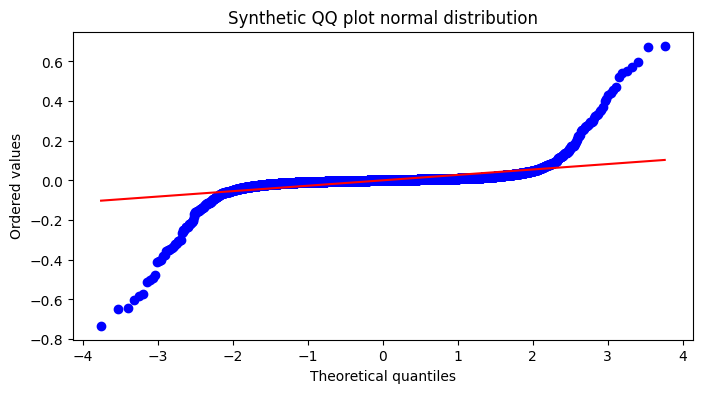

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(synthetic_data.reshape(-1), plot=ax, dist="norm")
ax.set_title("Synthetic QQ plot normal distribution")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

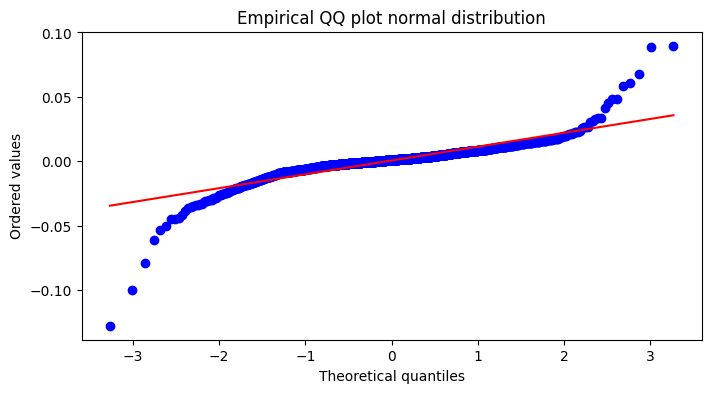

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

res = stats.probplot(empirical_window.reshape(-1), plot=ax, dist="norm")
ax.set_title("Empirical QQ plot normal distribution")
ax.set_ylabel("Ordered values")
ax.set_xlabel("Theoretical quantiles")
plt.show()

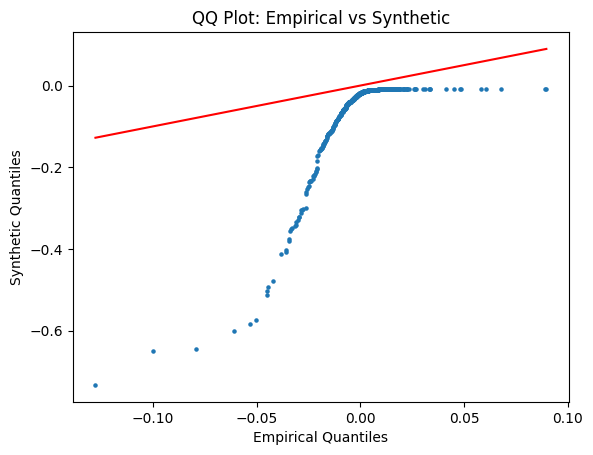

In [25]:
emp = np.sort(empirical_window.reshape(-1))
syn = np.sort(synthetic_data.reshape(-1))

n = min(len(emp), len(syn))

emp_q = emp[:n]
syn_q = syn[:n]

plt.scatter(emp_q, syn_q, s=5)
plt.plot(emp_q, emp_q, color='red') # reference target
plt.xlabel("Empirical Quantiles")
plt.ylabel("Synthetic Quantiles")
plt.title("QQ Plot: Empirical vs Synthetic")
plt.show()

In [26]:
kurtosis_emp = stats.kurtosis(empirical_window.reshape(-1))
skew_emp = stats.skew(empirical_window.reshape(-1))
kurtosis_syn = stats.kurtosis(synthetic_data.reshape(-1))
skew_syn = stats.skew(synthetic_data.reshape(-1))

print("="*10 + "Empirical" + "="*10)
print(f"Kurtosis : {kurtosis_emp}\nSkewness : {skew_emp}")

print("="*10 + "Synthetic" + "="*10)
print(f"Kurtosis : {kurtosis_syn}\nSkewness : {skew_syn}")

==========Empirical==========
Kurtosis : 22.206419445577147
Skewness : -1.153432131576969
==========Synthetic==========
Kurtosis : 90.21157166781391
Skewness : -0.6370147645384662


## Intra-Window Evaluation

In [27]:
lags=32

In [28]:
def compute_acf_matrix(windows, lags):
  return np.array([
      acf(w, nlags=lags, fft=True)
      for w in windows
  ])

In [29]:
empirical_window.shape

(5, 256)

In [30]:
b = torch.randint(0, 10, (2,2))
print(b.numpy())
print(np.percentile(b, 5, axis=0))
print(np.percentile(b, 95, axis=0))

[[3 2]
 [9 6]]
[3.3 2.2]
[8.7 5.8]


In [31]:
acf_emp = compute_acf_matrix(empirical_window, lags)
acf_syn = compute_acf_matrix(synthetic_data[:5], lags)

mean_emp = acf_emp.mean(axis=0)
mean_syn = acf_syn.mean(axis=0)

low_emp = np.percentile(acf_emp[1:], 5, axis=0)
high_emp = np.percentile(acf_emp[1:], 95, axis=0)

low_syn = np.percentile(acf_syn[1:], 5, axis=0)
high_syn = np.percentile(acf_syn[1:], 95, axis=0)

decay_emp = np.sum(np.abs(acf_emp[:, 1:]), axis=1)
decay_syn = np.sum(np.abs(acf_syn[:, 1:]), axis=1)

In [32]:
ks_res = stats.ks_2samp(decay_emp, decay_syn)
ks_res

KstestResult(statistic=np.float64(0.8), pvalue=np.float64(0.07936507936507936), statistic_location=np.float64(1.9323689246826152), statistic_sign=np.int8(1))

In [33]:
wd = stats.wasserstein_distance(mean_emp[1:], mean_syn[1:])
scale = max(mean_emp[1:].max(), mean_syn[1:].max())
print(wd / scale)

0.2395562164260751


In [34]:
def get_residuals(window, lags=1):
    model = AutoReg(window, lags=lags, old_names=False).fit()
    return model.resid

res_emp = np.array([get_residuals(w) for w in empirical_window])
res_syn = np.array([get_residuals(w) for w in synthetic_data[:5]])

def arch_test(residuals):
    stat, pval, _, _ = sm.stats.diagnostic.het_arch(residuals)
    return pval

arch_emp = [arch_test(r) for r in res_emp]
arch_syn = [arch_test(r) for r in res_syn]

In [35]:
arch_emp, arch_syn

([np.float64(0.7441624730613718),
  np.float64(0.0001522775515397478),
  np.float64(6.6263849430865605e-09),
  np.float64(2.216361968139896e-11),
  np.float64(0.0003303071088673368)],
 [np.float64(1.4183098397898245e-09),
  np.float64(8.752538404194346e-11),
  np.float64(5.552671800779537e-18),
  np.float64(9.287506675515542e-19),
  np.float64(7.797358664991371e-13)])

### Conclusion
1) The model generate stationarity fixed-window segment returns, which correlates with most financial return properties 
2) Although the baseline model reproduces the general shape of the empirical return distribution, it fails to accurately capture the scale, as evidenced by deviations in the tails of the QQ plot, suggesting an overestimation of extreme values

3) The ARCH test results, despite being based on a limited number of windows, indicate that volatility clustering is present in most empirical windows, supporting the use of GARCH-type models. In contrast, the synthetic data exhibits consistently stronger ARCH effects across all windows, suggesting that the model overestimates the strength and persistence of conditional heteroskedasticity.

4) While distribution plots provide a general sense of similarity, they can be misleading. The comparison of average ACF values reveals noticeable discrepancies between empirical and synthetic data. Using the Wasserstein distance as a measure of distributional difference, the normalized gap indicates a meaningful mismatch in temporal dependence structure. This suggests that the model struggles to capture the correct scale and short-term dynamics, despite reproducing the presence of conditional heteroskedasticity within windows in an exaggerated manner.

### GARCH Evaluation under Fixed Window Segmentation

In [153]:
def compute_arch(windows, mean="constant", vol="GARCH", p=1, q=1):
  result = []
  n = len(windows)

  for i in range(n):
    model = arch_model(
      windows[i] * 100,
      mean=mean,
      vol=vol,
      p=p,
      q=q
    )

    res = model.fit()
    result.append(res)

  return result

arch_emp = compute_arch(empirical_window)
arch_syn = compute_arch(synthetic_data)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 762285733.7201126
Iteration:      2,   Func. Count:     14,   Neg. LLF: 224720991.0487742
Iteration:      3,   Func. Count:     22,   Neg. LLF: 187.2229778816225
Iteration:      4,   Func. Count:     28,   Neg. LLF: 146.73705204012523
Iteration:      5,   Func. Count:     33,   Neg. LLF: 146.63970059428044
Iteration:      6,   Func. Count:     39,   Neg. LLF: 146.6031447192804
Iteration:      7,   Func. Count:     45,   Neg. LLF: 146.49691723642377
Iteration:      8,   Func. Count:     50,   Neg. LLF: 146.57348540144056
Iteration:      9,   Func. Count:     56,   Neg. LLF: 146.48142773407886
Iteration:     10,   Func. Count:     62,   Neg. LLF: 146.47818420349688
Iteration:     11,   Func. Count:     67,   Neg. LLF: 146.47818294130747
Iteration:     12,   Func. Count:     71,   Neg. LLF: 146.47818294130718
Optimization terminated successfully    (Exit mode 0)
            Current function value: 146.47818294130747
            Iterati

In [235]:
window_emp = arch_emp[0]
print(window_emp.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -146.478
Distribution:                  Normal   AIC:                           300.956
Method:            Maximum Likelihood   BIC:                           315.137
                                        No. Observations:                  256
Date:                Wed, Apr 08 2026   Df Residuals:                      255
Time:                        10:47:36   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0708  2.658e-02      2.664  7.711e-03 [1.873e-0

In [156]:
window_syn = arch_syn[0]
print(window_syn.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -461.225
Distribution:                  Normal   AIC:                           930.450
Method:            Maximum Likelihood   BIC:                           944.631
                                        No. Observations:                  256
Date:                Wed, Apr 08 2026   Df Residuals:                      255
Time:                        10:47:36   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0578  6.831e-02      0.847      0.397 [-7.60

In [205]:
def split_significance(results, param_name, alpha=0.05):
  sig = []
  nonsig = []
  
  for res in results:
      value = res.params[param_name]
      pval = res.pvalues[param_name]
      
      if pval < alpha:
          sig.append(value)
      else:
          nonsig.append(value)
  
  return sig, nonsig

In [206]:
def significance_ratio(results, param_name, alpha=0.05):
    sig_count = sum(res.pvalues[param_name] < alpha for res in results)
    return sig_count / len(results)

In [207]:
def make_bounds(values, tol=0.1):
  if len(values) == 0:
      return (None, None)
  
  vmin = min(values)
  vmax = max(values)
  width = vmax - vmin
  
  return (vmin - tol * width, vmax + tol * width)

In [208]:
def compare_range_estimate(bounds, data):
    epsilon = 1e-6
    if len(data) == 0:
        return 0

    min_val, max_val = bounds
    in_bound = sum(min_val - epsilon <= value <= max_val + epsilon for value in data)

    return in_bound / len(data)

In [209]:
alpha_emp_sig_ratio = significance_ratio(arch_emp, "alpha[1]") 
mu_emp_sig_ratio = significance_ratio(arch_emp, "mu") 
omega_emp_sig_ratio = significance_ratio(arch_emp, "omega") 
beta_emp_sig_ratio = significance_ratio(arch_emp, "beta[1]") 

alpha_syn_sig_ratio = significance_ratio(arch_syn, "alpha[1]") 
mu_syn_sig_ratio = significance_ratio(arch_syn, "mu") 
omega_syn_sig_ratio = significance_ratio(arch_syn, "omega") 
beta_syn_sig_ratio = significance_ratio(arch_syn, "beta[1]") 

alpha_emp_sig, alpha_emp_nonsig = split_significance(arch_emp, "alpha[1]")
omega_emp_sig, omega_emp_nonsig = split_significance(arch_emp, "omega")
beta_emp_sig, beta_emp_nonsig   = split_significance(arch_emp, "beta[1]")
mu_emp_sig, mu_emp_nonsig       = split_significance(arch_emp, "mu")

alpha_syn_sig, alpha_syn_nonsig = split_significance(arch_syn, "alpha[1]")
omega_syn_sig, omega_syn_nonsig = split_significance(arch_syn, "omega")
beta_syn_sig, beta_syn_nonsig   = split_significance(arch_syn, "beta[1]")
mu_syn_sig, mu_syn_nonsig       = split_significance(arch_syn, "mu")

alpha_bounds_sig = make_bounds(alpha_emp_sig)
omega_bounds_sig = make_bounds(omega_emp_sig)
beta_bounds_sig  = make_bounds(beta_emp_sig)
mu_bounds_sig    = make_bounds(mu_emp_sig)

alpha_bounds_nonsig = make_bounds(alpha_emp_nonsig)
omega_bounds_nonsig = make_bounds(omega_emp_nonsig)
beta_bounds_nonsig  = make_bounds(beta_emp_nonsig)
mu_bounds_nonsig    = make_bounds(mu_emp_nonsig)

In [210]:
coverage_alpha_sig = compare_range_estimate(alpha_bounds_sig, alpha_syn_sig) 
coverage_mu_sig = compare_range_estimate(mu_bounds_sig, mu_syn_sig) 
coverage_omega_sig = compare_range_estimate(omega_bounds_sig, omega_syn_sig) 
coverage_beta_sig = compare_range_estimate(beta_bounds_sig, beta_syn_sig) 

coverage_alpha_nonsig = compare_range_estimate(alpha_bounds_nonsig, alpha_syn_nonsig) 
# coverage_mu_nonsig = compare_range_estimate(mu_bounds_nonsig, mu_syn_nonsig)
coverage_omega_nonsig = compare_range_estimate(omega_bounds_nonsig, omega_syn_nonsig) 
# coverage_beta_nonsig = compare_range_estimate(beta_bounds_nonsig, beta_syn_nonsig) 

In [217]:
print("="*10 + "Empirical" + "="*10)
print("Alpha : ", alpha_emp_sig_ratio)
print("Omega : ", omega_emp_sig_ratio)
print("Beta : ", beta_emp_sig_ratio)
print("Mu : ", mu_emp_sig_ratio)

print("="*10 + "Synthetic" + "="*10)
print("Alpha : ", alpha_syn_sig_ratio)
print("Omega : ", omega_syn_sig_ratio)
print("Beta : ", beta_syn_sig_ratio)
print("Mu : ", mu_syn_sig_ratio)

==========Empirical==========
Alpha :  0.8
Omega :  0.4
Beta :  1.0
Mu :  1.0
==========Synthetic==========
Alpha :  0.65625
Omega :  0.625
Beta :  0.78125
Mu :  0.53125


In [241]:
print("="*10 + "Significant Coverage" + "="*10)
print("Alpha : ", coverage_alpha_sig)
print("Mu : ", coverage_mu_sig)
print("Omega : ", coverage_omega_sig)
print("Beta : ", coverage_beta_sig)

print("="*10 + "Non-Significant Coverage" + "="*10)
print("Alpha : ", coverage_alpha_nonsig)
print("Omega : ", coverage_omega_nonsig)

==========Significant Coverage==========
Alpha :  0.42857142857142855
Mu :  0.5294117647058824
Omega :  0.55
Beta :  0.8
==========Non-Significant Coverage==========
Alpha :  0.09090909090909091
Omega :  0.75
